# Quantization

Quantize the trained Keras model to full INT8 TensorFlow Lite, export `quantized_model/model.tflite`, `gen/model.c`, and `gen/model.h`, then evaluate the quantized model and optionally predict images in `pred_capture/`.


In [1]:
from pathlib import Path
import os
import keras
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from preprocess import LABELS, NUM_CLASSES
from utils.export_tflite import write_model_c_file, write_model_h_file

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
tf.get_logger().setLevel("ERROR")

SCRIPT_DIR = Path.cwd()
GEN_DIR = SCRIPT_DIR / "quantized_model"
SAVED_MODEL_DIR = SCRIPT_DIR / "saved_model"
KERAS_MODEL_PATH = SAVED_MODEL_DIR / "mobilenetv2_3class_classifier.keras"
X_TRAIN_PATH = SAVED_MODEL_DIR / "x_train.npy"
TFLITE_MODEL_PATH = GEN_DIR / "model.tflite"
MODEL_C_PATH = GEN_DIR / "model.c"
MODEL_H_PATH = GEN_DIR / "model.h"
DATA_ROOT = SCRIPT_DIR / "../data"

IMAGE_SIZE = (160, 160)
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp"}
REPRESENTATIVE_DATASET_SAMPLES = 512
CLASS_NAMES = [name for name, _ in sorted(LABELS.items(), key=lambda item: item[1])]


In [2]:
def representative_indices(num_samples: int, max_samples: int = REPRESENTATIVE_DATASET_SAMPLES) -> np.ndarray:
    if num_samples <= 0:
        raise ValueError("Representative dataset requires at least one sample.")
    if num_samples <= max_samples:
        return np.arange(num_samples, dtype=np.int32)
    return np.linspace(0, num_samples - 1, num=max_samples, dtype=np.int32)


def export_model_to_tflite(model: keras.Model, x_train: np.ndarray) -> bytes:
    converter = tf.lite.TFLiteConverter.from_keras_model(model)

    def representative_dataset():
        for i in representative_indices(len(x_train)):
            yield [x_train[i:i + 1].astype(np.float32)]

    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    return converter.convert()


def resolve_model_img_size(model: keras.Model) -> int:
    input_shape = model.input_shape[0] if isinstance(model.input_shape, list) else model.input_shape
    if len(input_shape) != 4:
        raise ValueError(f"Expected 4D model input shape, got {input_shape}")

    height, width, channels = input_shape[1:]
    if None in (height, width, channels):
        raise ValueError(f"Model input shape must be fully defined, got {input_shape}")
    if channels != 3 or height != width:
        raise ValueError(f"Expected square RGB input, got {input_shape}")
    return int(height)


def export_artifacts(tflite_model: bytes, img_size: int):
    GEN_DIR.mkdir(exist_ok=True)

    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]
    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    defines = {
        "IMG_SIZE": img_size,
        "NUM_CLASSES": NUM_CLASSES,
        "INPUT_SCALE": f"{input_scale}f",
        "INPUT_ZERO_POINT": input_zero_point,
        "OUTPUT_SCALE": f"{output_scale}f",
        "OUTPUT_ZERO_POINT": output_zero_point,
    }
    declarations = [
        f'// Labels: {", ".join(f"{name}={idx}" for name, idx in sorted(LABELS.items(), key=lambda item: item[1]))}',
    ]

    TFLITE_MODEL_PATH.write_bytes(tflite_model)
    write_model_h_file(MODEL_H_PATH, defines, declarations)
    write_model_c_file(MODEL_C_PATH, tflite_model)

    print(f"Input scale:       {input_scale}")
    print(f"Input zero point:  {input_zero_point}")
    print(f"Output scale:      {output_scale}")
    print(f"Output zero point: {output_zero_point}")
    print(f"Model size:        {len(tflite_model) / 1024:.1f} KB")
    print(f"Saved: {TFLITE_MODEL_PATH}")
    print(f"Saved: {MODEL_C_PATH}")
    print(f"Saved: {MODEL_H_PATH}")


def load_image_array(image_path: Path, image_size=IMAGE_SIZE) -> np.ndarray:
    image = keras.utils.load_img(image_path, target_size=image_size, keep_aspect_ratio=True)
    array = keras.utils.img_to_array(image).astype(np.float32)
    return preprocess_input(array)


def load_test_split(data_root: Path):
    x_test, y_test = [], []
    for class_name in CLASS_NAMES:
        split_dir = data_root / class_name / "test"
        if not split_dir.exists():
            raise FileNotFoundError(f"Missing test split: {split_dir.resolve()}")

        for image_path in sorted(split_dir.iterdir()):
            if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS:
                x_test.append(load_image_array(image_path))
                y_test.append(LABELS[class_name])

    if not x_test:
        raise ValueError(f"No test images found under {data_root.resolve()}")
    return np.stack(x_test).astype(np.float32), np.array(y_test, dtype=np.int32)


def load_tflite_interpreter(model_path: Path):
    interpreter = tf.lite.Interpreter(model_path=str(model_path))
    interpreter.allocate_tensors()
    return interpreter, interpreter.get_input_details()[0], interpreter.get_output_details()[0]


def resize_to_tflite_input(images: np.ndarray, input_details: dict) -> np.ndarray:
    input_shape = tuple(input_details["shape"])
    expected_shape = tuple(input_shape[1:])
    if input_shape[0] != 1 or input_shape[3] != 3:
        raise ValueError(f"Unexpected model input shape: {input_shape}")
    if images.shape[1:] == expected_shape:
        return images
    return tf.image.resize(images, input_shape[1:3], method="bilinear").numpy().astype(np.float32)


def predict_tflite(interpreter, input_details, output_details, images: np.ndarray) -> np.ndarray:
    if input_details["dtype"] != np.int8:
        raise ValueError(f"Expected int8 input tensor, got {input_details['dtype']}")

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]
    quantized_images = images / input_scale + input_zero_point
    quantized_images = np.clip(quantized_images, -128, 127).astype(np.int8)

    raw_predictions = np.empty((len(images), NUM_CLASSES), dtype=np.int8)
    for i, image in enumerate(quantized_images):
        interpreter.set_tensor(input_details["index"], image[None, ...])
        interpreter.invoke()
        raw_predictions[i] = interpreter.get_tensor(output_details["index"])[0]

    return (raw_predictions.astype(np.float32) - output_zero_point) * output_scale


## Export INT8 TFLite Model


In [3]:
if not KERAS_MODEL_PATH.exists():
    raise FileNotFoundError(f"Model not found: {KERAS_MODEL_PATH.resolve()}")
if not X_TRAIN_PATH.exists():
    raise FileNotFoundError(f"Calibration data not found: {X_TRAIN_PATH.resolve()}")

print(f"Loading Keras model: {KERAS_MODEL_PATH.resolve()}")
model = keras.models.load_model(KERAS_MODEL_PATH)
img_size = resolve_model_img_size(model)

print(f"Loading calibration data: {X_TRAIN_PATH.resolve()}")
x_train = np.load(X_TRAIN_PATH)
if x_train.ndim != 4:
    raise ValueError(f"Expected x_train to be 4D, got shape {x_train.shape}")
if x_train.shape[1:] != (img_size, img_size, 3):
    raise ValueError(f"Calibration data shape {x_train.shape} does not match model input size {img_size}")

tflite_model = export_model_to_tflite(model, x_train)
export_artifacts(tflite_model, img_size)


Loading Keras model: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\saved_model\mobilenetv2_3class_classifier.keras
Loading calibration data: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\saved_model\x_train.npy


c:\Users\Rifki\.conda\envs\TF\lib\site-packages\tensorflow\lite\python\convert.py:766: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn("Statistics for quantized inputs were expected, but not "


Input scale:       0.007843137718737125
Input zero point:  -1
Output scale:      0.00390625
Output zero point: -128
Model size:        772.5 KB
Saved: c:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\quantized_model\model.tflite
Saved: c:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\quantized_model\model.c
Saved: c:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\quantized_model\model.h


## Evaluate Quantized TFLite Model


In [4]:
if not TFLITE_MODEL_PATH.exists():
    raise FileNotFoundError(f"Missing quantized model: {TFLITE_MODEL_PATH}")
if not DATA_ROOT.exists():
    raise FileNotFoundError(f"Missing data root: {DATA_ROOT.resolve()}")

x_test, y_test = load_test_split(DATA_ROOT)
interpreter, input_details, output_details = load_tflite_interpreter(TFLITE_MODEL_PATH)
x_test = resize_to_tflite_input(x_test, input_details)

predictions = predict_tflite(interpreter, input_details, output_details, x_test)
y_pred = np.argmax(predictions, axis=1)
accuracy = np.mean(y_pred == y_test)
cm = confusion_matrix(y_test, y_pred)

print(f"Model: {TFLITE_MODEL_PATH}")
print(f"Test samples: {len(x_test)}")
print(f"Quantized accuracy: {accuracy:.4f}")
print()
print("Classification report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))
print("Confusion matrix:")
print(cm)


Model: c:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\quantized_model\model.tflite
Test samples: 540
Quantized accuracy: 0.9556

Classification report:
              precision    recall  f1-score   support

       Amine     0.9082    0.9889    0.9468       180
       Rifki     0.9779    0.9833    0.9806       180
       Jakub     0.9877    0.8944    0.9388       180

    accuracy                         0.9556       540
   macro avg     0.9579    0.9556    0.9554       540
weighted avg     0.9579    0.9556    0.9554       540

Confusion matrix:
[[178   1   1]
 [  2 177   1]
 [ 16   3 161]]


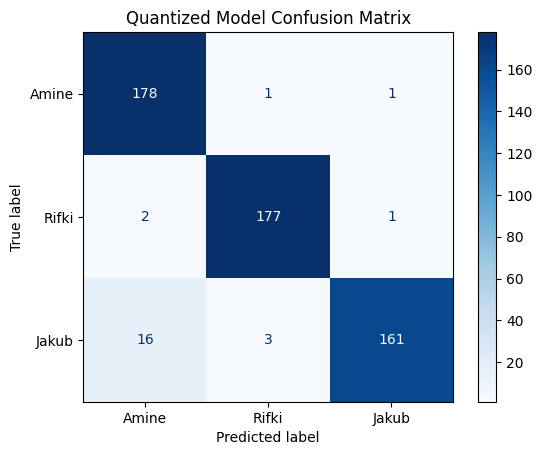

In [5]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap="Blues", values_format="d")
plt.title("Quantized Model Confusion Matrix")
plt.show()
